In [1]:
!pip install xgboost shap imbalanced-learn

In [2]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Imbalanced data
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Explainability
import shap

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

In [3]:
import sklearn, xgboost, shap, imblearn

print(f"scikit-learn : {sklearn.__version__}")
print(f"xgboost      : {xgboost.__version__}")
print(f"shap         : {shap.__version__}")
print(f"imbalanced   : {imblearn.__version__}")
print("All libraries loaded successfully!")

scikit-learn : 1.6.1
xgboost      : 3.2.0
shap         : 0.52.0
imbalanced   : 0.14.2
All libraries loaded successfully!


In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)        # expect (7043, 21)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Shape: (7043, 21)

Column types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

First 5 rows:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male       

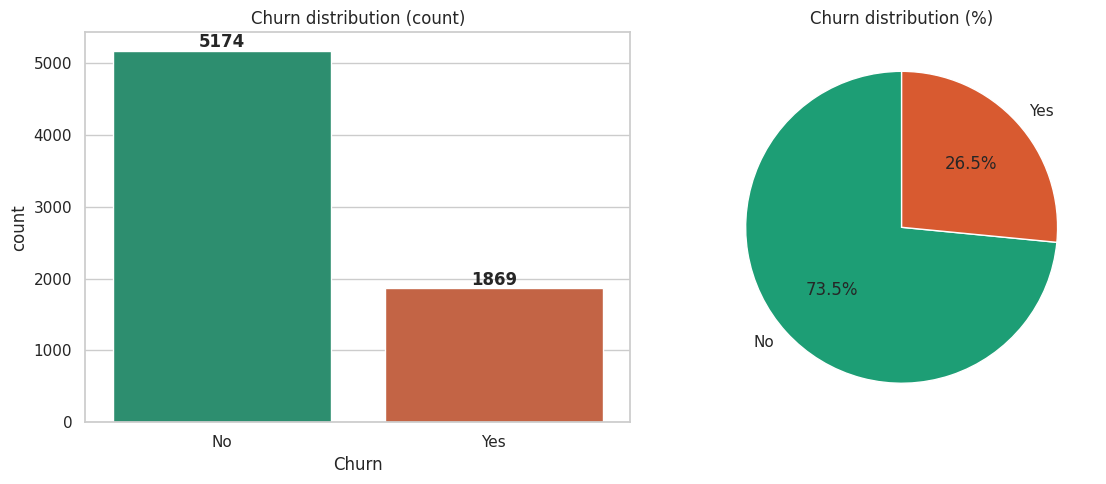

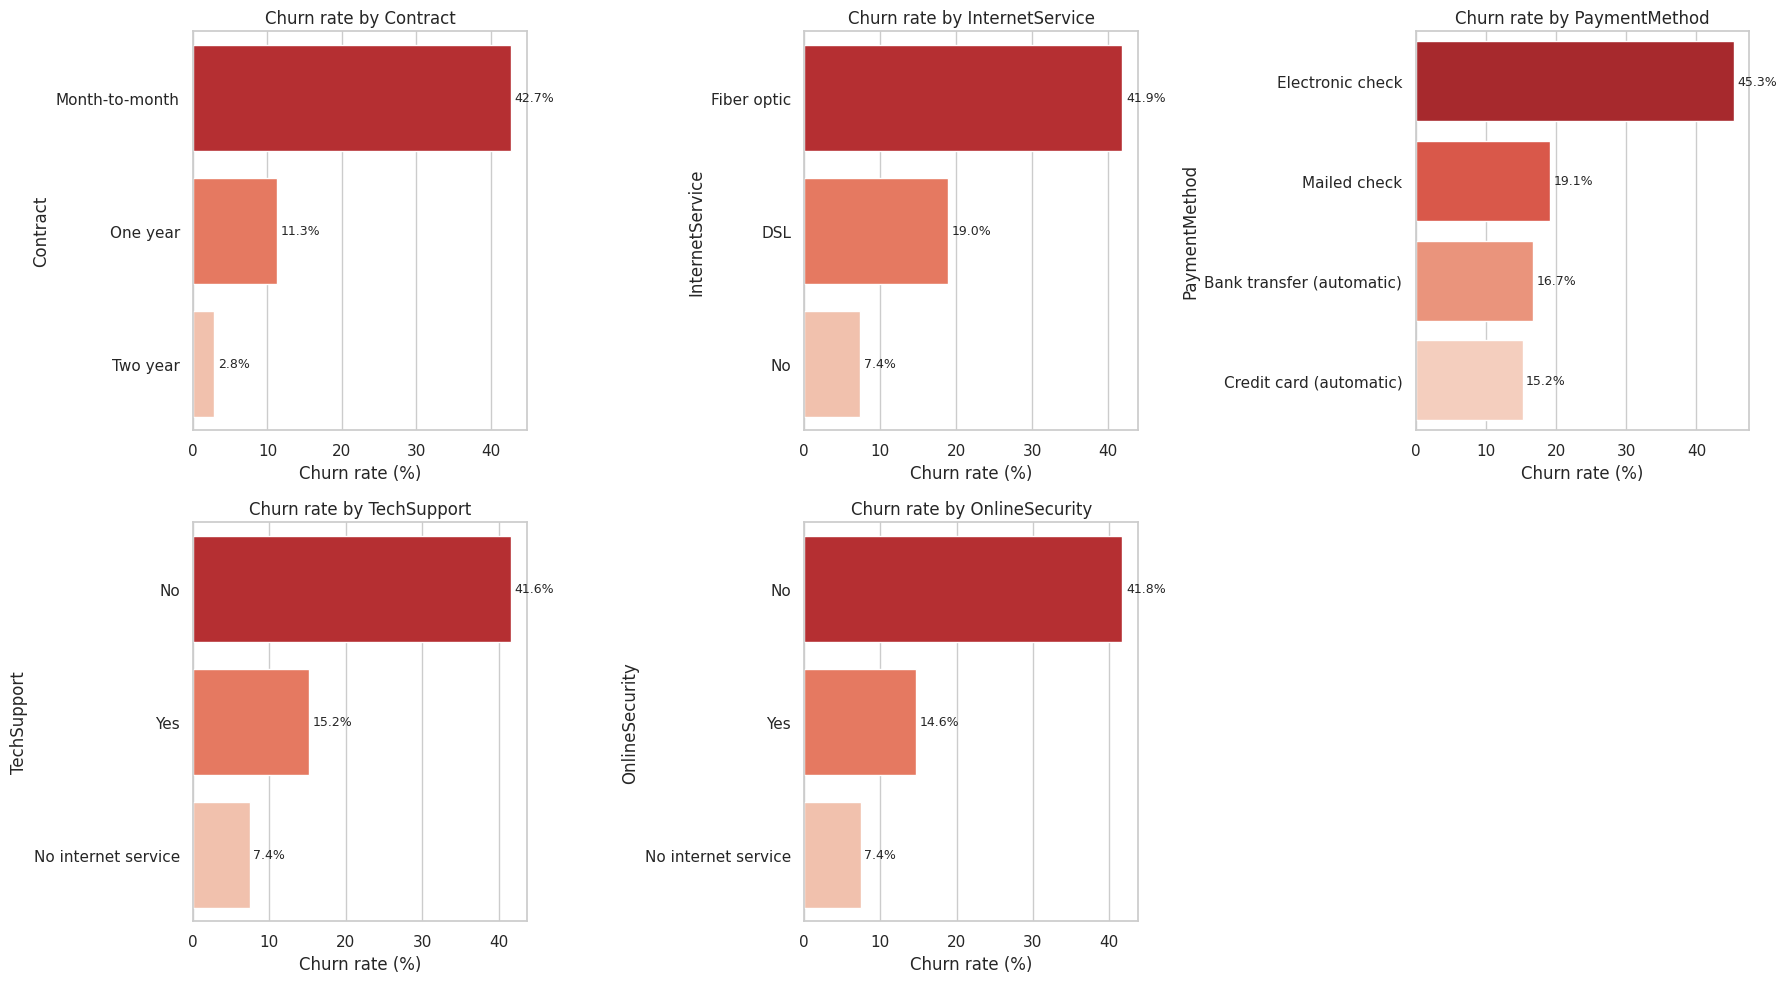

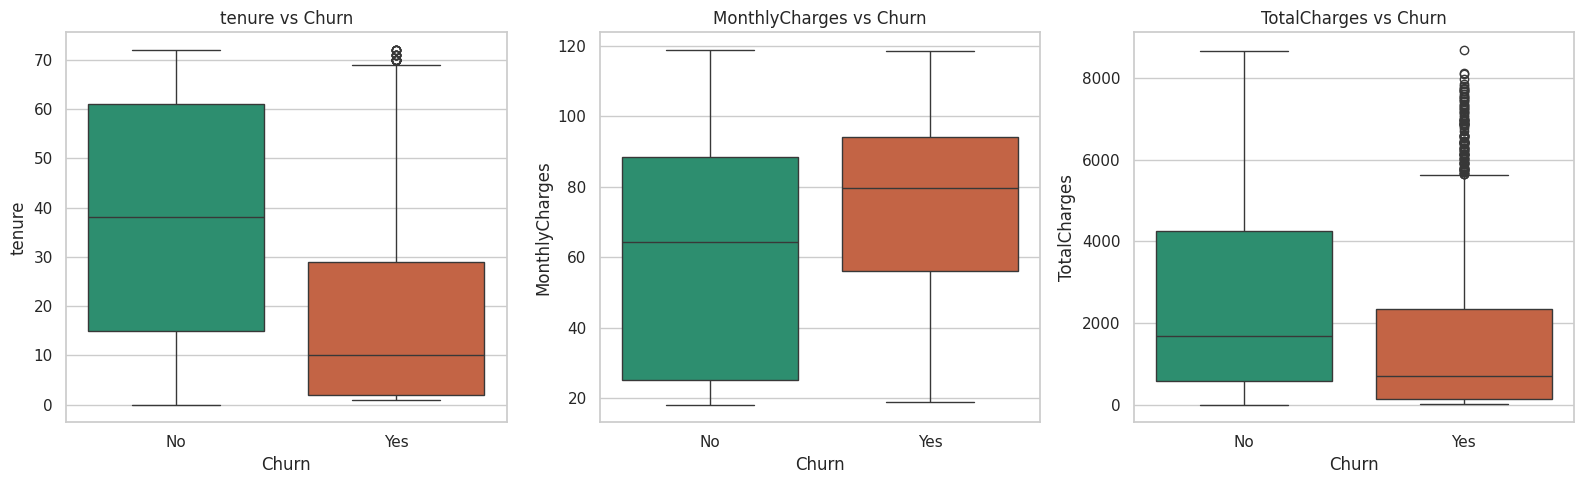


Top 15 features correlated with churn:
tenure                                 -0.352229
InternetService_Fiber optic             0.308020
Contract_Two year                      -0.302253
PaymentMethod_Electronic check          0.301919
InternetService_No                     -0.227890
OnlineSecurity_No internet service     -0.227890
DeviceProtection_No internet service   -0.227890
TechSupport_No internet service        -0.227890
StreamingMovies_No internet service    -0.227890
StreamingTV_No internet service        -0.227890
OnlineBackup_No internet service       -0.227890
TotalCharges                           -0.198324
MonthlyCharges                          0.193356
PaperlessBilling_Yes                    0.191825
Contract_One year                      -0.177820
Name: Churn_numeric, dtype: float64


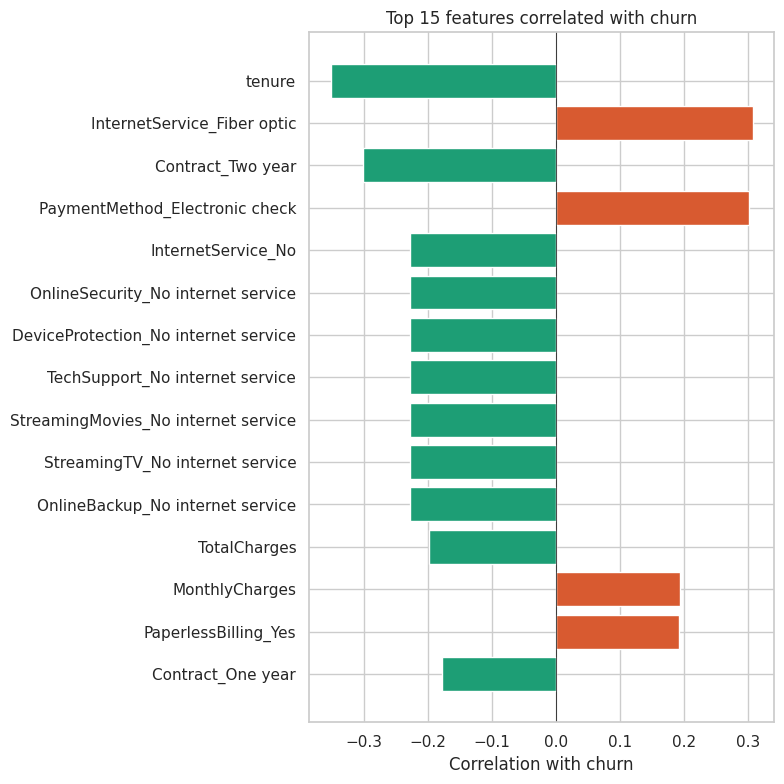

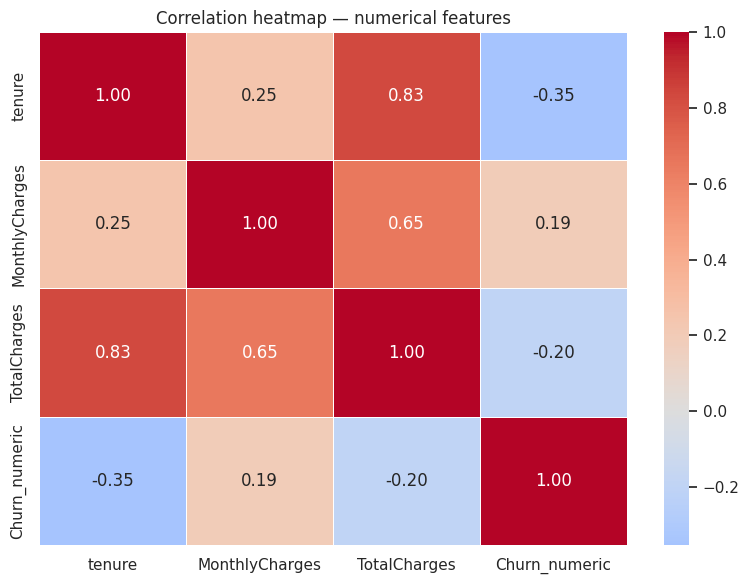


KEY EDA FINDINGS
1. Overall churn rate: 26.5%
2. Highest-risk contract type: Month-to-month
3. Avg tenure (churned): 18.0 months
4. Avg tenure (retained): 37.6 months
5. Top positive correlation with churn: tenure (-0.352)


In [5]:
# ============================================
# 1. LOAD DATA & INITIAL INSPECTION
# ============================================
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())


# ============================================
# 2. MISSING VALUES CHECK
# ============================================
# TotalCharges is often loaded as object dtype with blank strings
# for new customers (tenure = 0), so convert it properly first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct.round(2)
}).query('missing_count > 0').sort_values('missing_count', ascending=False)

print("\nMissing values summary:")
print(missing_df)

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Handle missing TotalCharges — these are customers with tenure=0
# (just signed up), so fill with 0 rather than dropping rows
df['TotalCharges'] = df['TotalCharges'].fillna(0)


# ============================================
# 3. CHURN DISTRIBUTION (target variable)
# ============================================
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("\nChurn distribution:")
print(churn_counts)
print("\nChurn percentage:")
print(churn_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#1D9E75', '#D85A30'],
              legend=False, ax=axes[0])
axes[0].set_title('Churn distribution (count)')
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_pct, labels=churn_pct.index, autopct='%1.1f%%',
            colors=['#1D9E75', '#D85A30'], startangle=90)
axes[1].set_title('Churn distribution (%)')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

# Key insight to note: this dataset is imbalanced (~26-27% churn)
# → justifies using SMOTE later in preprocessing


# ============================================
# 4. CHURN vs KEY CATEGORICAL FEATURES
# ============================================
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod',
                     'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)

    sns.barplot(x=churn_rate.values, y=churn_rate.index,
                hue=churn_rate.index, palette='Reds_r', legend=False, ax=axes[i])
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_xlabel('Churn rate (%)')
    for j, v in enumerate(churn_rate.values):
        axes[i].text(v + 0.5, j, f'{v:.1f}%', va='center', fontsize=9)

axes[-1].axis('off')  # hide the unused 6th subplot
plt.tight_layout()
plt.savefig('churn_by_categorical.png', dpi=150)
plt.show()


# ============================================
# 5. CHURN vs NUMERICAL FEATURES (tenure, charges)
# ============================================
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Churn', y=col, hue='Churn',
                palette=['#1D9E75', '#D85A30'], legend=False, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')

plt.tight_layout()
plt.savefig('numerical_vs_churn.png', dpi=150)
plt.show()


# ============================================
# 6. CORRELATION ANALYSIS
# ============================================
# Encode target and key categoricals numerically for correlation
df_corr = df.copy()
df_corr['Churn_numeric'] = (df_corr['Churn'] == 'Yes').astype(int)

# One-hot encode categoricals for a fuller correlation view
cat_cols_for_corr = df_corr.select_dtypes(include='object').columns.drop(
    ['customerID', 'Churn']
)
df_encoded = pd.get_dummies(df_corr, columns=cat_cols_for_corr, drop_first=True)

# Correlation of every feature with churn, sorted
corr_with_churn = df_encoded.corr(numeric_only=True)['Churn_numeric'] \
    .drop('Churn_numeric') \
    .sort_values(key=abs, ascending=False)

print("\nTop 15 features correlated with churn:")
print(corr_with_churn.head(15))

# Plot top correlations
plt.figure(figsize=(8, 8))
top_corr = corr_with_churn.head(15)
colors = ['#D85A30' if v > 0 else '#1D9E75' for v in top_corr.values]
plt.barh(top_corr.index, top_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Correlation with churn')
plt.title('Top 15 features correlated with churn')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_correlations.png', dpi=150)
plt.show()

# Full correlation heatmap (numerical features only)
plt.figure(figsize=(8, 6))
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']
sns.heatmap(df_corr[num_features].corr(), annot=True, cmap='coolwarm',
            center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation heatmap — numerical features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()


# ============================================
# 7. SUMMARY OF KEY FINDINGS (print for your report)
# ============================================
print("\n" + "="*50)
print("KEY EDA FINDINGS")
print("="*50)
print(f"1. Overall churn rate: {churn_pct['Yes']:.1f}%")
print(f"2. Highest-risk contract type: {df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()).idxmax()}")
print(f"3. Avg tenure (churned): {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"4. Avg tenure (retained): {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print(f"5. Top positive correlation with churn: {corr_with_churn.index[0]} ({corr_with_churn.iloc[0]:.3f})")

In [6]:
# ============================================
# 1. DROP UNNECESSARY COLUMNS
# ============================================
# customerID is just an identifier — no predictive value
df_model = df.copy()
df_model = df_model.drop('customerID', axis=1)


# ============================================
# 2. ENCODE TARGET VARIABLE
# ============================================
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)


# ============================================
# 3. FEATURE ENGINEERING — create new features
# ============================================
# Bin tenure into groups — often more predictive than raw tenure
def tenure_group(t):
    if t <= 12:
        return '0-12'
    elif t <= 24:
        return '13-24'
    elif t <= 48:
        return '25-48'
    elif t <= 60:
        return '49-60'
    else:
        return '61-72'

df_model['tenure_group'] = df_model['tenure'].apply(tenure_group)

# Average monthly spend ratio — flags customers paying more than expected for their tenure
df_model['avg_monthly_spend'] = df_model['TotalCharges'] / (df_model['tenure'] + 1)  # +1 avoids div by zero

# Count of additional services subscribed (engagement signal)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df_model['num_services'] = df_model[service_cols].apply(
    lambda row: sum(row == 'Yes'), axis=1
)

print("New features created: tenure_group, avg_monthly_spend, num_services")
print(df_model[['tenure_group', 'avg_monthly_spend', 'num_services']].head())


# ============================================
# 4. SEPARATE FEATURE TYPES
# ============================================
# Binary columns (Yes/No, Male/Female) — map directly to 0/1
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    df_model[col] = df_model[col].map(
        {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
    )

# Multi-category columns — need one-hot encoding
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport',
                   'StreamingTV', 'StreamingMovies', 'Contract',
                   'PaymentMethod', 'tenure_group']

df_model = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=True)

print(f"\nShape after encoding: {df_model.shape}")


# ============================================
# 5. SEPARATE FEATURES & TARGET
# ============================================
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")


# ============================================
# 6. TRAIN-TEST SPLIT (before scaling/SMOTE — avoid data leakage)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserves the ~27% churn ratio in both sets
)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}, Test churn rate: {y_test.mean():.3f}")


# ============================================
# 7. SCALE NUMERICAL FEATURES
# ============================================
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'num_services']

scaler = StandardScaler()

# Fit ONLY on training data, then apply to both — prevents test set leakage
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nNumerical features scaled (mean=0, std=1)")
print(X_train[numerical_cols].describe().round(2))


# ============================================
# 8. HANDLE CLASS IMBALANCE WITH SMOTE
# ============================================
# Apply SMOTE only to training data — never touch the test set,
# or you'll get artificially inflated performance metrics
print(f"\nBefore SMOTE: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE: {y_train_smote.value_counts().to_dict()}")


# ============================================
# 9. FINAL SANITY CHECKS
# ============================================
print("\n" + "="*50)
print("PREPROCESSING SUMMARY")
print("="*50)
print(f"Original dataset shape: {df.shape}")
print(f"Final feature count: {X_train_smote.shape[1]}")
print(f"Training samples (after SMOTE): {X_train_smote.shape[0]}")
print(f"Test samples (untouched): {X_test.shape[0]}")
print(f"Any nulls in X_train_smote: {X_train_smote.isnull().sum().sum()}")
print(f"Any nulls in X_test: {X_test.isnull().sum().sum()}")

# These four variables go straight into Phase 4 model training:
# X_train_smote, y_train_smote, X_test, y_test

New features created: tenure_group, avg_monthly_spend, num_services
  tenure_group  avg_monthly_spend  num_services
0         0-12          14.925000             1
1        25-48          53.985714             2
2         0-12          36.050000             2
3        25-48          40.016304             3
4         0-12          50.550000             0

Shape after encoding: (7043, 37)

Feature matrix shape: (7043, 36)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Train shape: (5634, 36), Test shape: (1409, 36)
Train churn rate: 0.265, Test churn rate: 0.265

Numerical features scaled (mean=0, std=1)
        tenure  MonthlyCharges  TotalCharges  avg_monthly_spend  num_services
count  5634.00         5634.00       5634.00            5634.00       5634.00
mean     -0.00           -0.00          0.00               0.00          0.00
std       1.00            1.00          1.00               1.00          1.00
min      -1.32           -1.54         -1.01       

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1035
           1       0.54      0.67      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

ROC-AUC: 0.8349

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1035
           1       0.53      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC: 0.8384

Best XGBoost params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2}

XGBOOST RESULTS (tuned)
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1035
           1       0.54      

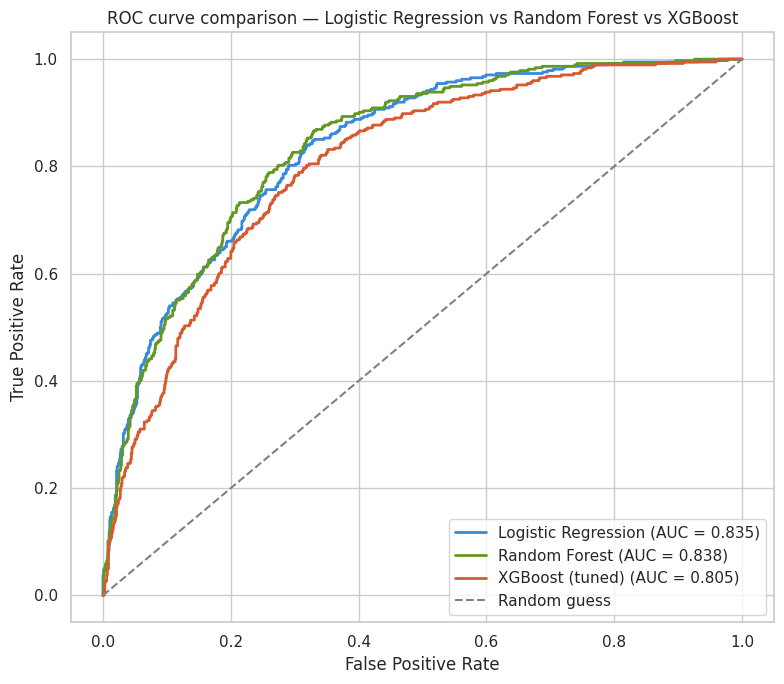

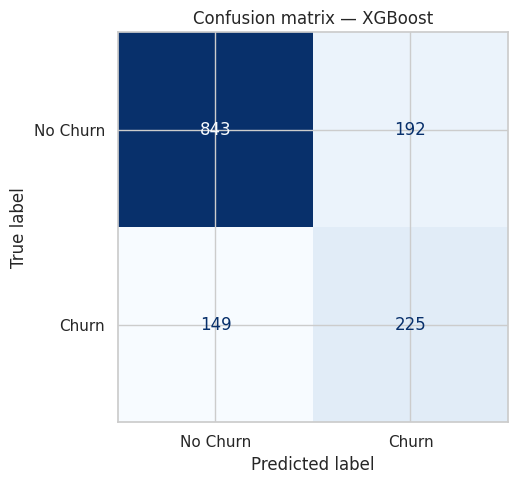

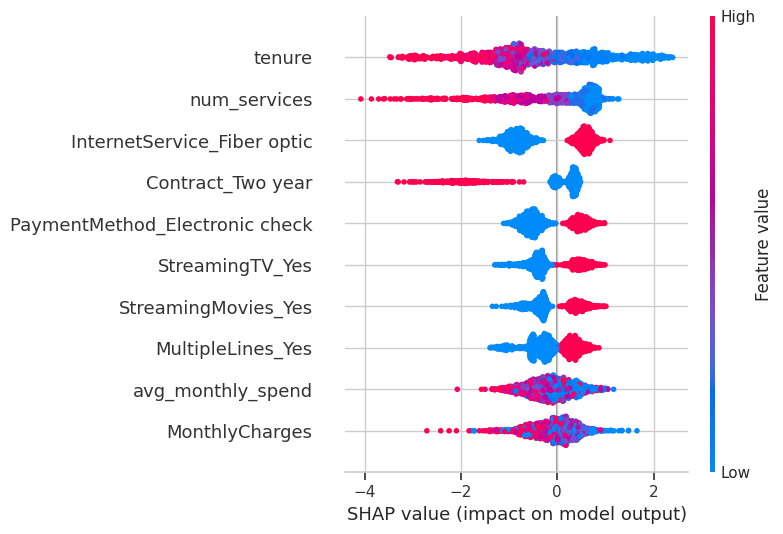

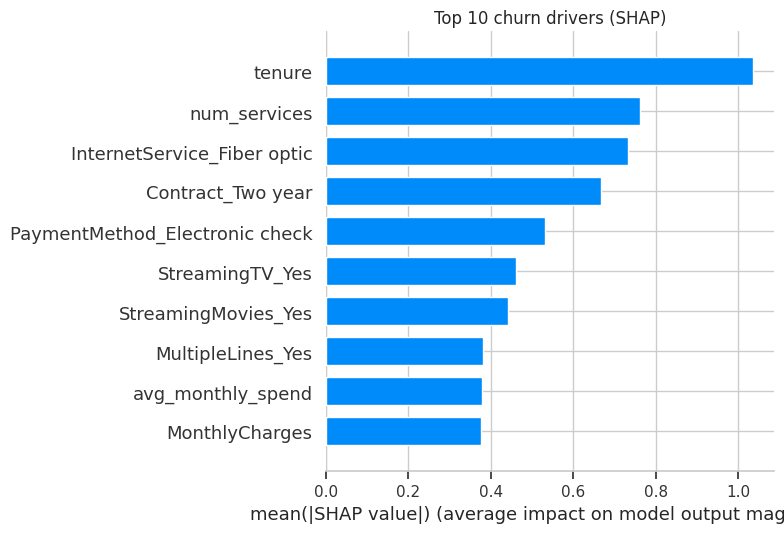


All plots saved: roc_comparison.png, confusion_matrix_xgb.png, shap_summary.png, shap_bar.png
model_comparison.csv saved with all metrics


In [7]:
# ============================================
# 1. TRAIN MODEL 1 — LOGISTIC REGRESSION (baseline)
# ============================================
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")


# ============================================
# 2. TRAIN MODEL 2 — RANDOM FOREST
# ============================================
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")


# ============================================
# 3. TRAIN MODEL 3 — XGBOOST (with hyperparameter tuning)
# ============================================
xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# RandomizedSearchCV is faster than GridSearchCV for this many combinations
from sklearn.model_selection import RandomizedSearchCV

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=15,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_smote, y_train_smote)
xgb_best = xgb_search.best_estimator_

print("\nBest XGBoost params:", xgb_search.best_params_)

y_pred_xgb = xgb_best.predict(X_test)
y_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("XGBOOST RESULTS (tuned)")
print("="*50)
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")


# ============================================
# 4. SIDE-BY-SIDE MODEL COMPARISON TABLE
# ============================================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models_results = {
    'Logistic Regression': (y_pred_lr, y_proba_lr),
    'Random Forest': (y_pred_rf, y_proba_rf),
    'XGBoost (tuned)': (y_pred_xgb, y_proba_xgb)
}

comparison = []
for name, (pred, proba) in models_results.items():
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

comparison_df = pd.DataFrame(comparison).round(3)
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
print(comparison_df.to_string(index=False))

comparison_df.to_csv('model_comparison.csv', index=False)


# ============================================
# 5. ROC CURVES — ALL THREE MODELS ON ONE CHART
# ============================================
plt.figure(figsize=(8, 7))

colors = {'Logistic Regression': '#378ADD', 'Random Forest': '#639922', 'XGBoost (tuned)': '#D85A30'}

for name, (pred, proba) in models_results.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})',
             color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve comparison — Logistic Regression vs Random Forest vs XGBoost')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150)
plt.show()


# ============================================
# 6. CONFUSION MATRIX — BEST MODEL (assume XGBoost wins)
# ============================================
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion matrix — XGBoost')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', dpi=150)
plt.show()


# ============================================
# 7. SHAP EXPLAINABILITY — TOP CHURN DRIVERS
# ============================================
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test)

# Summary plot — shows feature impact direction and magnitude
plt.figure()
shap.summary_plot(shap_values, X_test, show=False, max_display=10)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar plot — clean ranked feature importance (good for slides)
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=10)
plt.title('Top 10 churn drivers (SHAP)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll plots saved: roc_comparison.png, confusion_matrix_xgb.png, shap_summary.png, shap_bar.png")
print("model_comparison.csv saved with all metrics")

Churn probability distribution:
count    7043.000000
mean        0.292838
std         0.355445
min         0.000017
25%         0.009411
50%         0.083126
75%         0.631625
max         0.999088
Name: churn_probability, dtype: float64

Risk segment summary:
              customer_count  avg_monthly_charge  avg_tenure
risk_segment                                                
High risk               1608               77.54       17.09
Low risk                4853               60.86       39.42
Medium risk              582               62.02       15.86


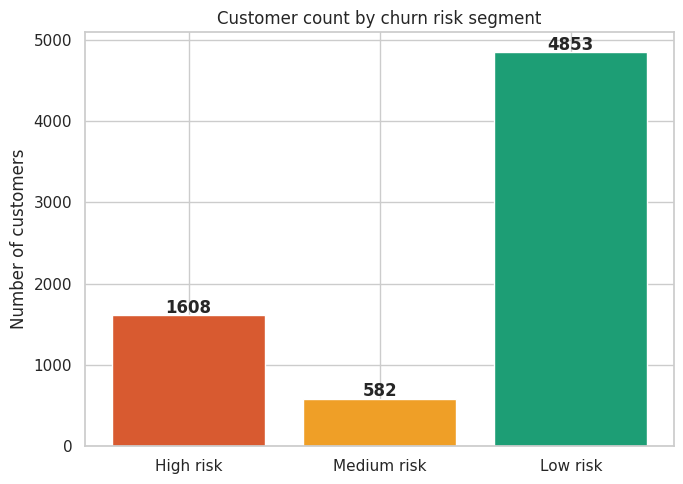


High-risk customers: 1608
Avg monthly charge (high risk): $77.54
Monthly revenue at risk: $124,687.30
Annual revenue at risk: $1,496,247.60

--- Retention campaign projection (at 35% save rate) ---
Customers retained: 563
Revenue saved/month: $43,640.55
Campaign cost/month: $24,120.00
Net benefit/month: $19,520.55
Net benefit/year: $234,246.66

Exported 2190 at-risk customers to high_risk_customers.csv
      customerID  churn_probability risk_segment        Contract  tenure  \
2184  4695-WJZUE           0.999088    High risk  Month-to-month       2   
3822  6137-NICCO           0.998834    High risk  Month-to-month       6   
5     9305-CDSKC           0.998359    High risk  Month-to-month       8   
353   0219-YTZUE           0.997946    High risk  Month-to-month       4   
39    8168-UQWWF           0.997686    High risk  Month-to-month      11   
4517  2012-NWRPA           0.997460    High risk  Month-to-month      11   
3346  2545-EBUPK           0.996630    High risk  Month-to-mo

In [8]:
# ============================================
# 1. GENERATE CHURN RISK SCORES FOR ALL CUSTOMERS
# ============================================
# Use the full dataset (not just test set) to score every customer
X_full_scaled = X.copy()
X_full_scaled[numerical_cols] = scaler.transform(X_full_scaled[numerical_cols])

churn_probabilities = xgb_best.predict_proba(X_full_scaled)[:, 1]

# Attach scores back to original dataframe for business-readable output
risk_df = df.copy()
risk_df['churn_probability'] = churn_probabilities

print("Churn probability distribution:")
print(risk_df['churn_probability'].describe())


# ============================================
# 2. SEGMENT CUSTOMERS BY RISK LEVEL
# ============================================
def risk_segment(prob):
    if prob >= 0.7:
        return 'High risk'
    elif prob >= 0.4:
        return 'Medium risk'
    else:
        return 'Low risk'

risk_df['risk_segment'] = risk_df['churn_probability'].apply(risk_segment)

segment_summary = risk_df.groupby('risk_segment').agg(
    customer_count=('customerID', 'count'),
    avg_monthly_charge=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean')
).round(2)

print("\nRisk segment summary:")
print(segment_summary)

# Visualize segment sizes
plt.figure(figsize=(7, 5))
segment_counts = risk_df['risk_segment'].value_counts().reindex(['High risk', 'Medium risk', 'Low risk'])
colors_seg = ['#D85A30', '#EF9F27', '#1D9E75']
plt.bar(segment_counts.index, segment_counts.values, color=colors_seg)
for i, v in enumerate(segment_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.title('Customer count by churn risk segment')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.savefig('risk_segments.png', dpi=150)
plt.show()


# ============================================
# 3. REVENUE IMPACT CALCULATION
# ============================================
high_risk = risk_df[risk_df['risk_segment'] == 'High risk']

high_risk_count = len(high_risk)
avg_monthly_charge_high_risk = high_risk['MonthlyCharges'].mean()

# Monthly revenue currently at risk
monthly_revenue_at_risk = high_risk_count * avg_monthly_charge_high_risk
annual_revenue_at_risk = monthly_revenue_at_risk * 12

print(f"\nHigh-risk customers: {high_risk_count}")
print(f"Avg monthly charge (high risk): ${avg_monthly_charge_high_risk:.2f}")
print(f"Monthly revenue at risk: ${monthly_revenue_at_risk:,.2f}")
print(f"Annual revenue at risk: ${annual_revenue_at_risk:,.2f}")

# Assume a retention campaign with realistic save rate (industry benchmark: 30-40%)
save_rate = 0.35
retention_cost_per_customer = 15  # e.g. cost of a discount/offer per customer per month

customers_saved = high_risk_count * save_rate
revenue_saved_monthly = customers_saved * avg_monthly_charge_high_risk
campaign_cost_monthly = high_risk_count * retention_cost_per_customer
net_benefit_monthly = revenue_saved_monthly - campaign_cost_monthly

print(f"\n--- Retention campaign projection (at {save_rate*100:.0f}% save rate) ---")
print(f"Customers retained: {customers_saved:.0f}")
print(f"Revenue saved/month: ${revenue_saved_monthly:,.2f}")
print(f"Campaign cost/month: ${campaign_cost_monthly:,.2f}")
print(f"Net benefit/month: ${net_benefit_monthly:,.2f}")
print(f"Net benefit/year: ${net_benefit_monthly*12:,.2f}")


# ============================================
# 4. EXPORT HIGH-RISK CUSTOMER LIST (for retention team / dashboard)
# ============================================
export_cols = ['customerID', 'churn_probability', 'risk_segment', 'Contract',
               'tenure', 'MonthlyCharges', 'TechSupport', 'OnlineSecurity']

high_risk_export = risk_df[risk_df['risk_segment'].isin(['High risk', 'Medium risk'])][export_cols]
high_risk_export = high_risk_export.sort_values('churn_probability', ascending=False)
high_risk_export.to_csv('high_risk_customers.csv', index=False)

print(f"\nExported {len(high_risk_export)} at-risk customers to high_risk_customers.csv")
print(high_risk_export.head(10))

In [9]:
# ============================================
# 1. SCORE THE FULL DATASET WITH THE FINAL XGBOOST MODEL
# ============================================
# Use the same preprocessing pipeline that was fit on training data —
# never re-fit the scaler here, or you'll get inconsistent values
X_full_scaled = X.copy()
X_full_scaled[numerical_cols] = scaler.transform(X_full_scaled[numerical_cols])

# Predict probabilities using the tuned XGBoost model from Phase 4
churn_probabilities = xgb_best.predict_proba(X_full_scaled)[:, 1]


# ============================================
# 2. BUILD THE RISK SEGMENT FROM MODEL OUTPUT
# ============================================
def risk_segment(prob):
    if prob >= 0.7:
        return 'High risk'
    elif prob >= 0.4:
        return 'Medium risk'
    else:
        return 'Low risk'

# Start from the ORIGINAL (unencoded, unscaled) dataframe so Power BI
# gets human-readable categorical values, not one-hot encoded columns
export_df = df.copy()
export_df['TotalCharges'] = pd.to_numeric(export_df['TotalCharges'], errors='coerce').fillna(0)

export_df['churn_probability'] = churn_probabilities
export_df['risk_segment'] = export_df['churn_probability'].apply(risk_segment)

# Round probability for cleaner display in Power BI (still precise enough for sorting)
export_df['churn_probability'] = export_df['churn_probability'].round(4)

In [10]:
# ============================================
# 3. SELECT & ORDER COLUMNS FOR THE EXPORT
# ============================================
# Keep original business-readable columns + the two new model outputs
export_cols = [
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
    'churn_probability', 'risk_segment'
]

final_export = export_df[export_cols]

# Sanity checks before saving
print("Shape:", final_export.shape)
print("\nRisk segment distribution:")
print(final_export['risk_segment'].value_counts())
print("\nChurn probability range:", final_export['churn_probability'].min(), "to", final_export['churn_probability'].max())
print("\nAny nulls:", final_export.isnull().sum().sum())

print(final_export.head())


# ============================================
# 4. SAVE THE ENRICHED CSV
# ============================================
final_export.to_csv('telco_churn_with_predictions.csv', index=False)
print("\nSaved: telco_churn_with_predictions.csv")

Shape: (7043, 23)

Risk segment distribution:
risk_segment
Low risk       4853
High risk      1608
Medium risk     582
Name: count, dtype: int64

Churn probability range: 0.0 to 0.9991000294685364

Any nulls: 0
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL     

In [11]:
import joblib

joblib.dump(xgb_best, "model.pkl")

print("Model saved successfully!")

Model saved successfully!
